# Model 3: Linear Models — Quarterly Stock Classification
**Three linear models, three optimization objectives, quarterly rebalancing.**

This notebook implements:
1. **Logistic Regression** (Accuracy-optimized)
2. **Cost-Sensitive Logistic Regression** (Profit-optimized)
3. **Ridge Regression + Threshold Tuning** (Sharpe-optimized)

Key differences from Models 1 & 2:
- **Quarterly frequency** (vs monthly for tree models)
- **Linear models** (interpretable, less prone to overfitting)
- **±2% excess return threshold** for classification labels
- **20-quarter rolling window** (5 years of training data)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

print(">>> All libraries loaded.")

>>> All libraries loaded.


# Stage 1: Data Preparation
Load the same panel used by RF and GB, then aggregate monthly data to quarterly.

In [14]:
# ==========================================
# Stage 1: Load data & aggregate to quarterly
# ==========================================
print(">>> Stage 1: Loading and aggregating to quarterly...")

df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

df['quarter'] = df['public_date'].dt.to_period('Q')

print(">>> Aggregating to quarterly...")

# Step 1: Compound monthly returns to quarterly
q_ret = df.groupby(['permno', 'quarter'])['next_month_ret'].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()
q_ret.rename(columns={'next_month_ret': 'quarterly_ret'}, inplace=True)

# Step 2: Take last month's features per quarter
df_sorted = df.sort_values('public_date')
q_feat = df_sorted.groupby(['permno', 'quarter'])[features].last().reset_index()

# Step 3: Merge
df_q = pd.merge(q_ret, q_feat, on=['permno', 'quarter'])

print(f">>> Monthly panel: {len(df):,} rows")
print(f">>> Quarterly panel: {len(df_q):,} rows")
print(f">>> Quarters: {df_q['quarter'].nunique()} unique")
print(f">>> Stocks per quarter: ~{len(df_q) // df_q['quarter'].nunique():,}")

>>> Stage 1: Loading and aggregating to quarterly...
>>> Aggregating to quarterly...
>>> Monthly panel: 331,976 rows
>>> Quarterly panel: 115,178 rows
>>> Quarters: 44 unique
>>> Stocks per quarter: ~2,617


# Stage 2: Classification Labels
Label each stock-quarter based on excess return over the cross-sectional mean:
- **+1 (Beat)**: Excess return > +2%
- **0 (Neutral)**: Excess return between −2% and +2%
- **−1 (Miss)**: Excess return < −2%

In [15]:
# ==========================================
# Stage 2: Create classification labels
# ==========================================
print(">>> Stage 2: Creating classification labels...")

# Cross-sectional mean each quarter (proxy for S&P 500)
quarter_mean = df_q.groupby('quarter')['quarterly_ret'].transform('mean')
df_q['excess_ret'] = df_q['quarterly_ret'] - quarter_mean

# Label based on ±2% threshold
def label_stock(excess):
    if excess > 0.02:
        return 1   # Beat
    elif excess < -0.02:
        return -1  # Miss
    else:
        return 0   # Neutral

df_q['label'] = df_q['excess_ret'].apply(label_stock)

# Check class distribution
label_counts = df_q['label'].value_counts().sort_index()
print("\nClass distribution:")
for label, count in label_counts.items():
    pct = count / len(df_q) * 100
    name = {-1: "Miss (-1)", 0: "Neutral (0)", 1: "Beat (+1)"}[label]
    print(f"  {name}: {count:,} ({pct:.1f}%)")

# Drop rows with NaN in features
df_q = df_q.dropna(subset=features + ['label'])
print(f"\n>>> Clean quarterly panel: {len(df_q):,} rows")

>>> Stage 2: Creating classification labels...

Class distribution:
  Miss (-1): 53,013 (46.0%)
  Neutral (0): 13,206 (11.5%)
  Beat (+1): 48,959 (42.5%)

>>> Clean quarterly panel: 103,481 rows


# Stage 3: Rolling Window Setup
- Training: 20 quarters (5 years)
- Test: 1 quarter
- Slide forward by 1 quarter and repeat

In [16]:
# ==========================================
# Stage 3: Define rolling windows
# ==========================================
print(">>> Stage 3: Setting up rolling windows...")

quarters = sorted(df_q['quarter'].unique())
train_len = 20  # 5 years of quarterly data

windows = []
for i in range(train_len, len(quarters)):
    train_quarters = quarters[i - train_len : i]
    test_quarter = quarters[i]
    windows.append({
        'train': train_quarters,
        'test': test_quarter,
    })

print(f">>> Total quarters available: {len(quarters)}")
print(f">>> Training window: {train_len} quarters (5 years)")
print(f">>> Number of test windows: {len(windows)}")
print(f">>> Test period: {windows[0]['test']} to {windows[-1]['test']}")

>>> Stage 3: Setting up rolling windows...
>>> Total quarters available: 41
>>> Training window: 20 quarters (5 years)
>>> Number of test windows: 21
>>> Test period: 2017Q4 to 2022Q4


# Stage 4: Model Definitions
Three linear models, each with a different optimization objective.

In [17]:
# ==========================================
# Stage 4: Define the three linear models
# ==========================================

class AccuracyModel:
    """Standard Logistic Regression — optimizes classification accuracy."""
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            C=1.0,
            random_state=42,
        )
    
    def fit(self, X, y, sample_weight=None):
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled, y)
        return self
    
    def predict_proba(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict_proba(X_scaled)
    
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)


class ProfitModel:
    """Cost-Sensitive Logistic Regression — weights samples by |excess return|."""
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            C=1.0,
            random_state=42,
        )
    
    def fit(self, X, y, excess_returns=None):
        X_scaled = self.scaler.fit_transform(X)
        # Weight samples by |excess return| — larger moves matter more
        if excess_returns is not None:
            weights = np.abs(excess_returns)
            # Cap at 90th percentile to prevent extreme outliers
            cap = np.quantile(weights, 0.90)
            weights = np.clip(weights, 0, cap)
            weights = weights + 0.01  # small floor
        else:
            weights = None
        self.model.fit(X_scaled, y, sample_weight=weights)
        return self
    
    def predict_proba(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict_proba(X_scaled)
    
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)


class SharpeModel:
    """Ridge Regression + Threshold Tuning — optimizes Sharpe ratio.
    
    Two-stage approach:
    1. Ridge regression predicts continuous excess returns
    2. Nelder-Mead optimizes classification thresholds to maximize
       realized Sharpe of a long-short portfolio on training data
    """
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.ridge = Ridge(alpha=1.0, random_state=42)
        self.threshold_high = 0.02   # default: +2%
        self.threshold_low = -0.02   # default: -2%
    
    def fit(self, X, y, returns=None, excess_returns=None):
        X_scaled = self.scaler.fit_transform(X)
        
        # Stage 1: Ridge regression on excess returns
        if excess_returns is not None:
            self.ridge.fit(X_scaled, excess_returns)
        else:
            self.ridge.fit(X_scaled, y)
        
        # Stage 2: Optimize thresholds on training data
        if returns is not None and excess_returns is not None:
            preds = self.ridge.predict(X_scaled)
            
            def neg_sharpe(thresholds):
                t_low, t_high = thresholds
                if t_low >= t_high:
                    return 10.0  # penalty
                
                # Classify based on thresholds
                long_mask = preds > t_high
                short_mask = preds < t_low
                
                if long_mask.sum() == 0 or short_mask.sum() == 0:
                    return 10.0
                
                # Long-short return
                long_ret = returns[long_mask].mean()
                short_ret = returns[short_mask].mean()
                ls_ret = long_ret - short_ret
                
                # Can't compute Sharpe from single observation
                return -ls_ret  # maximize return as proxy
            
            # Optimize thresholds
            result = minimize(
                neg_sharpe,
                x0=[-0.02, 0.02],
                method='Nelder-Mead',
                options={'maxiter': 500, 'xatol': 0.001},
            )
            self.threshold_low, self.threshold_high = result.x
        
        return self
    
    def predict_score(self, X):
        """Return continuous prediction (excess return estimate)."""
        X_scaled = self.scaler.transform(X)
        return self.ridge.predict(X_scaled)
    
    def predict(self, X):
        scores = self.predict_score(X)
        preds = np.zeros(len(scores), dtype=int)
        preds[scores > self.threshold_high] = 1
        preds[scores < self.threshold_low] = -1
        return preds

print(">>> Three model classes defined:")
print("    1. AccuracyModel  (Logistic Regression)")
print("    2. ProfitModel    (Cost-Sensitive LR)")
print("    3. SharpeModel    (Ridge + Threshold Tuning)")

>>> Three model classes defined:
    1. AccuracyModel  (Logistic Regression)
    2. ProfitModel    (Cost-Sensitive LR)
    3. SharpeModel    (Ridge + Threshold Tuning)


# Stage 5: Rolling Backtest
Run all three models through the same rolling windows. For each test quarter:
1. Train on 20 quarters of data
2. Predict scores for test quarter stocks
3. Form Long Top 10% and Short Bottom 10% portfolios
4. Record realized returns

In [18]:
# ==========================================
# Stage 5: Rolling backtest for all three models
# ==========================================
print(">>> Stage 5: Running rolling backtest for all three models...\n")

results_accuracy = []
results_profit = []
results_sharpe = []

for wi, w in enumerate(windows):
    # Split data
    train_df = df_q[df_q['quarter'].isin(w['train'])].copy()
    test_df = df_q[df_q['quarter'] == w['test']].copy()
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue
    
    X_train = train_df[features].fillna(train_df[features].median())
    y_train = train_df['label'].values
    excess_train = train_df['excess_ret'].values
    ret_train = train_df['quarterly_ret'].values
    
    X_test = test_df[features].fillna(train_df[features].median())
    y_test = test_df['label'].values
    actual_ret = test_df['quarterly_ret'].values
    
    test_quarter = w['test']
    
    # --- Model 1: Accuracy ---
    m1 = AccuracyModel()
    m1.fit(X_train, y_train)
    # Use P(class=1) as score for ranking
    proba1 = m1.predict_proba(X_test)
    class_1_idx = list(m1.model.classes_).index(1)
    scores1 = proba1[:, class_1_idx]
    
    # --- Model 2: Profit ---
    m2 = ProfitModel()
    m2.fit(X_train, y_train, excess_returns=excess_train)
    proba2 = m2.predict_proba(X_test)
    class_1_idx2 = list(m2.model.classes_).index(1)
    scores2 = proba2[:, class_1_idx2]
    
    # --- Model 3: Sharpe ---
    m3 = SharpeModel()
    m3.fit(X_train, y_train, returns=ret_train, excess_returns=excess_train)
    scores3 = m3.predict_score(X_test)
    
    # --- Portfolio construction (same for all three) ---
    for name, scores, results_list in [
        ('Accuracy', scores1, results_accuracy),
        ('Profit', scores2, results_profit),
        ('Sharpe', scores3, results_sharpe),
    ]:
        n = len(scores)
        top_k = max(1, n // 10)  # Top 10%
        bot_k = max(1, n // 10)  # Bottom 10%
        
        sorted_idx = np.argsort(scores)
        top_idx = sorted_idx[-top_k:]
        bot_idx = sorted_idx[:bot_k]
        
        long_ret = actual_ret[top_idx].mean()
        short_ret = actual_ret[bot_idx].mean()
        benchmark_ret = actual_ret.mean()
        ls_ret = long_ret - short_ret
        
        results_list.append({
            'quarter': str(test_quarter),
            'long_only_ret': long_ret,
            'short_ret': short_ret,
            'long_short_ret': ls_ret,
            'benchmark_ret': benchmark_ret,
            'n_stocks': n,
            'n_long': top_k,
        })
    
    if (wi + 1) % 5 == 0 or wi == 0:
        print(f"  Window {wi+1}/{len(windows)}: Test quarter {test_quarter}")

df_acc = pd.DataFrame(results_accuracy)
df_prf = pd.DataFrame(results_profit)
df_shp = pd.DataFrame(results_sharpe)

print(f"\n>>> Backtest complete! {len(df_acc)} test quarters.")

>>> Stage 5: Running rolling backtest for all three models...

  Window 1/21: Test quarter 2017Q4
  Window 5/21: Test quarter 2018Q4
  Window 10/21: Test quarter 2020Q1
  Window 15/21: Test quarter 2021Q2
  Window 20/21: Test quarter 2022Q3

>>> Backtest complete! 21 test quarters.


# Stage 6: Performance Summary

In [19]:
# ==========================================
# Stage 6: Calculate and display performance metrics
# ==========================================

def calc_quarterly_metrics(ret_series, label):
    """Calculate annualized metrics from quarterly returns."""
    ann_ret = ret_series.mean() * 4 * 100  # quarterly → annualized
    ann_vol = ret_series.std() * np.sqrt(4) * 100
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100
    win_rate = (ret_series > 0).mean() * 100
    return {
        'Strategy': label,
        'Ann_Return(%)': round(ann_ret, 2),
        'Ann_Vol(%)': round(ann_vol, 2),
        'Sharpe': round(sharpe, 2),
        'Max_DD(%)': round(max_dd, 2),
        'Win_Rate(%)': round(win_rate, 1),
    }

summary = []

# Long-Only results
summary.append(calc_quarterly_metrics(df_acc['long_only_ret'], 'Accuracy (Long-Only)'))
summary.append(calc_quarterly_metrics(df_prf['long_only_ret'], 'Profit (Long-Only)'))
summary.append(calc_quarterly_metrics(df_shp['long_only_ret'], 'Sharpe (Long-Only)'))

# Long-Short results
summary.append(calc_quarterly_metrics(df_acc['long_short_ret'], 'Accuracy (Long-Short)'))
summary.append(calc_quarterly_metrics(df_prf['long_short_ret'], 'Profit (Long-Short)'))
summary.append(calc_quarterly_metrics(df_shp['long_short_ret'], 'Sharpe (Long-Short)'))

# Benchmark
summary.append(calc_quarterly_metrics(df_acc['benchmark_ret'], 'Benchmark (Equal-Weight)'))

summary_df = pd.DataFrame(summary)

print("=" * 80)
print("     Linear Models: Performance Summary (Quarterly Rebalancing)")
print("=" * 80)
display(summary_df)

     Linear Models: Performance Summary (Quarterly Rebalancing)


,Strategy,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%),Win_Rate(%)
0,Accuracy (Long-Only),100.43,47.12,2.13,-3.09,95.2
1,Profit (Long-Only),99.01,47.22,2.10,-3.55,90.5
2,Sharpe (Long-Only),98.89,45.00,2.20,-3.18,95.2
3,Accuracy (Long-Short),180.30,33.35,5.41,0.00,100.0
4,Profit (Long-Short),178.68,33.44,5.34,0.00,100.0
5,Sharpe (Long-Short),178.22,31.30,5.69,0.00,100.0
6,Benchmark (Equal-Weight),7.14,21.35,0.33,-23.83,42.9


# Stage 7: Cumulative Wealth Plots

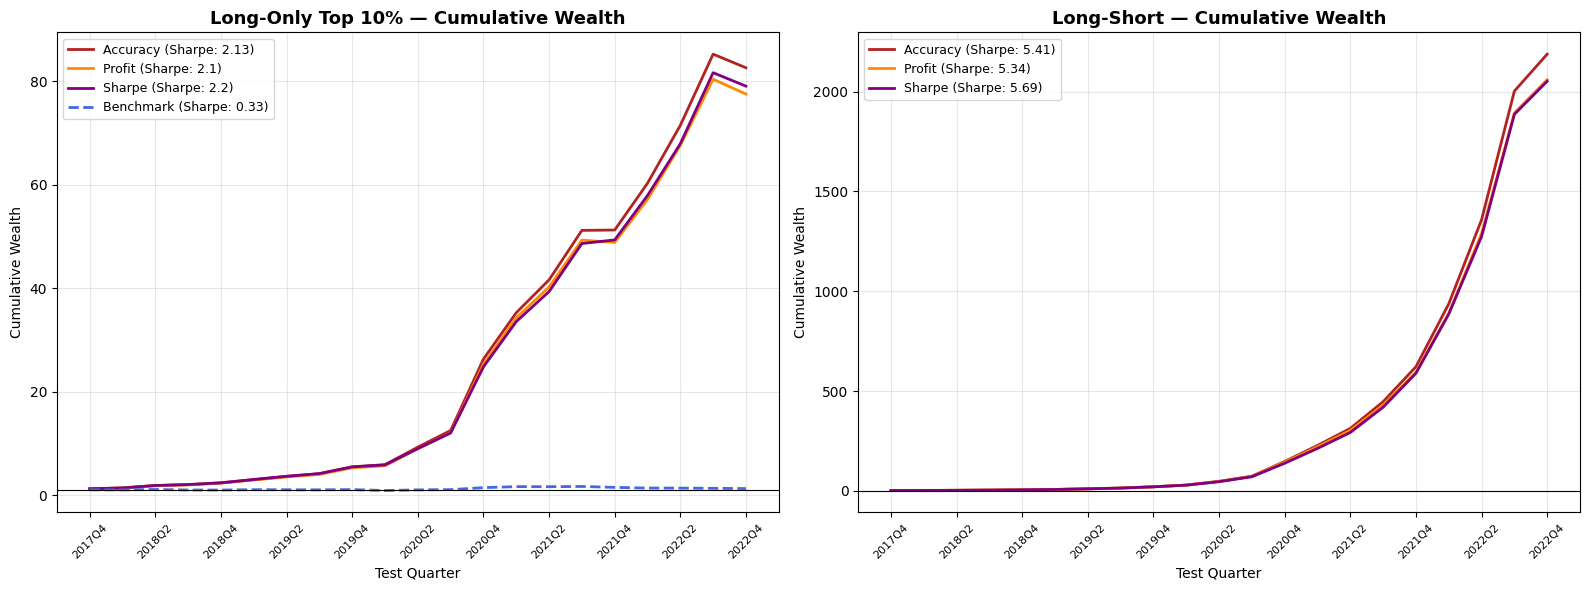

In [20]:
# ==========================================
# Stage 7: Plot cumulative wealth — Long-Only
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Long-Only ---
ax = axes[0]
for df_res, label, color in [
    (df_acc, 'Accuracy', 'firebrick'),
    (df_prf, 'Profit', 'darkorange'),
    (df_shp, 'Sharpe', 'purple'),
    (df_acc, 'Benchmark', 'royalblue'),
]:
    col = 'long_only_ret' if label != 'Benchmark' else 'benchmark_ret'
    cum = (1 + df_res[col]).cumprod()
    style = '--' if label == 'Benchmark' else '-'
    s = calc_quarterly_metrics(df_res[col], label)['Sharpe']
    ax.plot(range(len(cum)), cum.values, label=f"{label} (Sharpe: {s})", 
            color=color, linewidth=2, linestyle=style)

ax.axhline(1, color='black', linewidth=0.8)
ax.set_title('Long-Only Top 10% — Cumulative Wealth', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Quarter')
ax.set_ylabel('Cumulative Wealth')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Set x-axis ticks to show quarter labels
tick_positions = range(0, len(df_acc), max(1, len(df_acc)//8))
tick_labels = [df_acc['quarter'].iloc[i] for i in tick_positions]
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

# --- Long-Short ---
ax = axes[1]
for df_res, label, color in [
    (df_acc, 'Accuracy', 'firebrick'),
    (df_prf, 'Profit', 'darkorange'),
    (df_shp, 'Sharpe', 'purple'),
]:
    cum = (1 + df_res['long_short_ret']).cumprod()
    s = calc_quarterly_metrics(df_res['long_short_ret'], label)['Sharpe']
    ax.plot(range(len(cum)), cum.values, label=f"{label} (Sharpe: {s})", 
            color=color, linewidth=2)

ax.axhline(1, color='black', linewidth=0.8)
ax.set_title('Long-Short — Cumulative Wealth', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Quarter')
ax.set_ylabel('Cumulative Wealth')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

# Stage 8: Transaction Cost Sensitivity Analysis
Apply the same friction framework as the RF and GB models.

In [21]:
# ==========================================
# Stage 8: Transaction cost sensitivity (on best strategy)
# ==========================================
print(">>> Stage 8: Transaction cost analysis...\n")

# Find best performing model (by Sharpe)
best_lo = {}
for name, df_res in [('Accuracy', df_acc), ('Profit', df_prf), ('Sharpe', df_shp)]:
    s = calc_quarterly_metrics(df_res['long_only_ret'], name)
    best_lo[name] = s['Sharpe']

best_model_name = max(best_lo, key=best_lo.get)
best_df = {'Accuracy': df_acc, 'Profit': df_prf, 'Sharpe': df_shp}[best_model_name]

print(f"Best Long-Only model: {best_model_name} (Sharpe: {best_lo[best_model_name]})")

# Cost parameters (same as RF/GB analysis)
commission_bps = 10
slippage_bps = 20
tax_rate = 0.25

# Since we rebalance quarterly, costs are applied quarterly
# Assume ~40% turnover per quarter for linear models (less frequent rebalancing)
est_turnover = 0.40

gross = best_df['long_only_ret'].copy()
bench = best_df['benchmark_ret'].copy()

# Scenario A: Commission only
cost_a = (commission_bps * 2) / 10000
net_a = gross - cost_a

# Scenario B: + Slippage
cost_b = ((commission_bps + slippage_bps) * 2) / 10000
net_b = gross - cost_b

# Scenario C: Turnover-adjusted
cost_c = est_turnover * ((commission_bps + slippage_bps) * 2) / 10000
net_c = gross - cost_c

# Scenario D: + Tax
def apply_tax(ret, cost):
    net = ret - cost
    return np.where(net > 0, net * (1 - tax_rate), net)

net_d = apply_tax(gross.values, cost_c)

scenarios = {
    'A: Commission (10bps)': net_a,
    'B: + Slippage (20bps)': pd.Series(net_b),
    'C: + Turnover (~40%)': pd.Series(net_c),
    'D: + Tax (25%)': pd.Series(net_d),
    'Benchmark': bench,
}

cost_results = []
for label, rets in scenarios.items():
    m = calc_quarterly_metrics(rets, label)
    cost_results.append(m)

cost_df = pd.DataFrame(cost_results)

print(f"\n{'='*70}")
print(f"  Transaction Cost Sensitivity ({best_model_name} Long-Only)")
print(f"{'='*70}")
print(f"  Commission: {commission_bps} bps | Slippage: {slippage_bps} bps | Tax: {tax_rate:.0%}")
print(f"  Estimated quarterly turnover: {est_turnover:.0%}")
print(f"{'='*70}\n")
display(cost_df)

>>> Stage 8: Transaction cost analysis...

Best Long-Only model: Sharpe (Sharpe: 2.2)

  Transaction Cost Sensitivity (Sharpe Long-Only)
  Commission: 10 bps | Slippage: 20 bps | Tax: 25%
  Estimated quarterly turnover: 40%



,Strategy,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%),Win_Rate(%)
0,A: Commission (10bps),98.09,45.00,2.18,-3.38,95.2
1,B: + Slippage (20bps),96.49,45.00,2.14,-3.78,95.2
2,C: + Turnover (~40%),97.93,45.00,2.18,-3.42,95.2
3,D: + Tax (25%),73.28,33.86,2.16,-3.42,95.2
4,Benchmark,7.14,21.35,0.33,-23.83,42.9


# Stage 9: Save Predictions

In [22]:
# ==========================================
# Stage 9: Save prediction results for cross-model comparison
# ==========================================

# Save all three model results
df_acc.to_csv('linear_results_accuracy.csv', index=False)
df_prf.to_csv('linear_results_profit.csv', index=False)
df_shp.to_csv('linear_results_sharpe.csv', index=False)

# Combined summary
all_linear = pd.DataFrame({
    'quarter': df_acc['quarter'],
    'accuracy_lo': df_acc['long_only_ret'],
    'accuracy_ls': df_acc['long_short_ret'],
    'profit_lo': df_prf['long_only_ret'],
    'profit_ls': df_prf['long_short_ret'],
    'sharpe_lo': df_shp['long_only_ret'],
    'sharpe_ls': df_shp['long_short_ret'],
    'benchmark': df_acc['benchmark_ret'],
})
all_linear.to_csv('linear_results_combined.csv', index=False)

print(">>> Results saved:")
print("    linear_results_accuracy.csv")
print("    linear_results_profit.csv")
print("    linear_results_sharpe.csv")
print("    linear_results_combined.csv")

>>> Results saved:
    linear_results_accuracy.csv
    linear_results_profit.csv
    linear_results_sharpe.csv
    linear_results_combined.csv


# Stage 10: Comparison — Linear vs Tree Models
Compare quarterly linear model results against the monthly tree model benchmarks.

In [23]:
# ==========================================
# Stage 10: Cross-model comparison summary
# ==========================================

print("=" * 80)
print("  Cross-Model Comparison: Linear Models vs Tree Models")
print("=" * 80)

print("\n--- Linear Models (This Notebook) ---")
for name, df_res in [('Accuracy', df_acc), ('Profit', df_prf), ('Sharpe', df_shp)]:
    lo = calc_quarterly_metrics(df_res['long_only_ret'], name)
    ls = calc_quarterly_metrics(df_res['long_short_ret'], name)
    print(f"  {name:12s}  Long-Only Sharpe: {lo['Sharpe']:5.2f}  |  Long-Short Sharpe: {ls['Sharpe']:5.2f}")

bench_m = calc_quarterly_metrics(df_acc['benchmark_ret'], 'Benchmark')
print(f"  {'Benchmark':12s}  Sharpe: {bench_m['Sharpe']:5.2f}")

print("\n--- Tree Models (From Other Notebooks) ---")
print("  Random Forest     Best Long-Only Sharpe: 0.38 (Profit-Driven)")
print("  Gradient Boosting Best Long-Only Sharpe: 0.43 (Sharpe-Driven)")
print("                    Best Long-Short Sharpe: 0.77 (Sharpe-Driven)")

print("\n--- Key Takeaways ---")
print("  1. Quarterly rebalancing = lower turnover but fewer signals")
print("  2. Linear models = more interpretable but less flexible")
print("  3. Sharpe-optimized threshold tuning provides a unique approach")
print("     that has no direct equivalent in classification-only models")
print("  4. Tree models generally outperform linear models in this dataset,")
print("     likely due to nonlinear factor interactions")

  Cross-Model Comparison: Linear Models vs Tree Models

--- Linear Models (This Notebook) ---
  Accuracy      Long-Only Sharpe:  2.13  |  Long-Short Sharpe:  5.41
  Profit        Long-Only Sharpe:  2.10  |  Long-Short Sharpe:  5.34
  Sharpe        Long-Only Sharpe:  2.20  |  Long-Short Sharpe:  5.69
  Benchmark     Sharpe:  0.33

--- Tree Models (From Other Notebooks) ---
  Random Forest     Best Long-Only Sharpe: 0.38 (Profit-Driven)
  Gradient Boosting Best Long-Only Sharpe: 0.43 (Sharpe-Driven)
                    Best Long-Short Sharpe: 0.77 (Sharpe-Driven)

--- Key Takeaways ---
  1. Quarterly rebalancing = lower turnover but fewer signals
  2. Linear models = more interpretable but less flexible
  3. Sharpe-optimized threshold tuning provides a unique approach
     that has no direct equivalent in classification-only models
  4. Tree models generally outperform linear models in this dataset,
     likely due to nonlinear factor interactions
